# Pose 모델 결과 보고서

1차 모델이 그려 준 사람 뼈대(관절 33개)가 3초 동안 어떻게 움직였는지 보고, **서 있음(0)** 인지 **낙상(1)** 인지 판단하는 2차 모델(Pose 모델)을 만들고 평가한 기록입니다.

이 노트북의 표와 그림은 코드를 실제로 실행해서 나온 결과입니다.

**목차**
0. 한눈에 보기
1. 목표
2. Pose 모델을 만든 방법
3. 했던 일
4. 1차 뼈대 품질과 알림 동작
5. 성능 평가
6. 결론과 다음 단계

## 0. 한눈에 보기

- 정답 뼈대(MediaPipe)를 넣으면 낙상을 거의 완벽하게 구분합니다. Pose 모델 자체는 잘 동작합니다.
- 팀의 1차 모델(carewaveAI)이 만든 뼈대를 넣으면 구분이 약합니다. 낙상 움직임이 뼈대에 충분히 담기지 않았기 때문입니다.
- 참고로 따로 만든 1차 모델(carewaveTest)의 뼈대를 넣으면 더 잘 구분하는 경향이 있습니다. 다만 세션이 18개뿐이라 두 1차 모델의 차이가 확실하다고까지는 말할 수 없습니다.
- 설계서 목표 중 낙상 사건 90% 이상 알림은 정답 뼈대에서만 넘고, 시간당 오탐 1건 미만은 어느 경우에도 못 미칩니다.

| 넣은 뼈대 | 낙상 구분 점수 (AUROC, 같은 세션 18개) |
|---|---|
| 정답 뼈대 (MediaPipe) | 약 1.00 |
| carewaveTest 뼈대 | 약 0.94 |
| carewaveAI 뼈대 (팀의 1차 모델) | 약 0.77 |

정확한 숫자와 신뢰 범위는 5절에 있습니다.

**숫자 읽는 법**

이 보고서에 나오는 숫자의 뜻, 좋은 값, 현재 결과입니다. 아래 해석 문단도 이 기준으로 설명합니다.

| 이름 | 쉬운 뜻 | 좋은 값 | 이 보고서의 결과 |
|---|---|---|---|
| window(조각) | 3초짜리 묶음 하나(30프레임). 모델은 조각마다 낙상 확률을 냄 | - | - |
| AUROC | 낙상 조각과 낙상 아닌 조각을 하나씩 뽑았을 때, 모델이 낙상 쪽에 더 높은 확률을 줄 가능성 | 0.5는 동전 던지기(구분 못 함). 0.7~0.8은 약함, 0.9 이상이면 잘 구분, 1.0은 완벽 | 정답 1.00, carewaveTest 0.94, carewaveAI 0.77 |
| AUPRC | 낙상이라고 한 것 중 진짜 낙상 비율과, 진짜 낙상 중 찾아낸 비율을 함께 본 점수. 낙상이 드물수록 어려움 | 찍으면 약 0.03(낙상 비율). 0.5 이상이면 쓸 만하고 1.0이 완벽 | 정답 0.97, carewaveTest 0.36, carewaveAI 0.05 |
| 재현율 | 진짜 낙상 중 찾아낸 비율 | 0.9 이상 | 5.5 표 |
| 특이도 | 낙상이 아닌 조각 중 "아님"이라고 맞힌 비율 | 0.99 이상. 조각이 수천 개라서 1%만 틀려도 잘못된 알림이 수십 번 | 5.5 표 |
| 이벤트 재현율 | 실제 낙상 사건 중 알림이 울린 비율 | 0.9 이상 (설계서 목표) | 정답 1.0, 나머지 0.67 |
| 시간당 오탐 | 낙상이 아닌데 1시간 동안 잘못 울린 알림 수 | 1건 미만 (설계서 목표). 130건이면 약 28초마다 한 번 잘못 울리는 셈 | 정답 8, carewaveTest 106, carewaveAI 130 |
| 알림 지연 | 낙상이 시작되고 알림이 울리기까지 걸린 시간 | 짧을수록 좋음. 3초 창을 쓰므로 2초 안팎이 한계 | 정답 1.7초, carewaveTest 2.0초, carewaveAI 3.5초 |
| 오차(MPJPE) | 예측한 관절이 정답 관절에서 떨어진 평균 거리. 화면 가로·세로 길이를 1로 잰 값 | 작을수록 좋음. 사람 몸 크기가 화면의 약 0.31이고 평균 자세만 그려도 0.129라서, 그보다 충분히 낮아야 의미가 있음 | carewaveAI 0.115 |
| 맞힌 관절 비율(PCK) | 정답에서 화면 크기의 5% 이내에 있는 관절의 비율 | 높을수록 좋음 | 0.13 ~ 0.51 |
| 상관 | 두 값이 함께 움직이는 정도(-1 ~ 1) | 1에 가까울수록 정답과 똑같이 움직임, 0이면 관계없음 | 0.03 ~ 0.17 |
| 95% 범위 | 같은 실험을 다시 했을 때 점수가 움직일 것으로 보이는 범위 | 좁을수록 믿을 수 있음 | carewaveAI AUROC 0.57 ~ 0.97 |

In [1]:
import json, os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch
from IPython.display import display
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
for _c in [Path.cwd(), *Path.cwd().parents, Path.cwd() / "pose_model"]:
    if (_c / "configs" / "pose_branch.yaml").exists():
        os.chdir(_c)
        break
sys.path.insert(0, ".")
sys.path.insert(0, "data")
R = Path("D:/project/carewaveAI/carewave-csi-pose-estimation/round4_v1_final")
OUT = Path("outputs/pose_only")
NAME_AI, NAME_TEST, NAME_GT = "carewaveAI 뼈대(팀 1차)", "carewaveTest 뼈대", "정답 뼈대(MediaPipe)"
RUNS = {"1_carewaveAI_뼈대": NAME_AI, "2_carewaveTest_뼈대": NAME_TEST, "3_정답뼈대_기준선": NAME_GT}
COLORS = {NAME_AI: "#4c72b0", NAME_TEST: "#dd8452", NAME_GT: "#55a868"}
print("작업 폴더:", Path.cwd())

작업 폴더: D:\project\carewave2Model\CareWave-Action-Model\pose_model


## 1. 목표

설계서(CareWave 2차 서기·낙상 이진분류 융합모델 최종 설계서)에서 Pose 파트에 요구한 것입니다.

| 항목 | 내용 |
|---|---|
| 풀려는 문제 | 서기(0) / 낙상(1)을 구분하고, 낙상 사건이 났을 때 알림 보내기 |
| 입력 | **1차 모델이 예측한 관절 좌표.** 정답(MediaPipe) 좌표는 입력으로 쓰지 않음 |
| 최종 역할 | CSI 모델과 합쳐서(융합) 낙상 판단을 돕는 보조 신호 |
| 이번 범위 | Pose 단독 모델. "1차 뼈대만으로 낙상을 얼마나 구분하는가"를 확인 |
| 합격 기준(예시) | 낙상 사건 알림 90% 이상, 시간당 오탐 1건 미만 |
| 평가 원칙 | 녹화 단위로 나누기, 기준값(threshold)은 검증 데이터에서만 정하기, TEST는 마지막에 한 번만 |

## 2. Pose 모델을 만든 방법

### 2.1 전체 흐름
1차 모델은 팀원이 만든 것이고 **그대로 두었습니다.** 그 출력(뼈대)을 받아서 아래 파란색 이후를 만들었습니다.

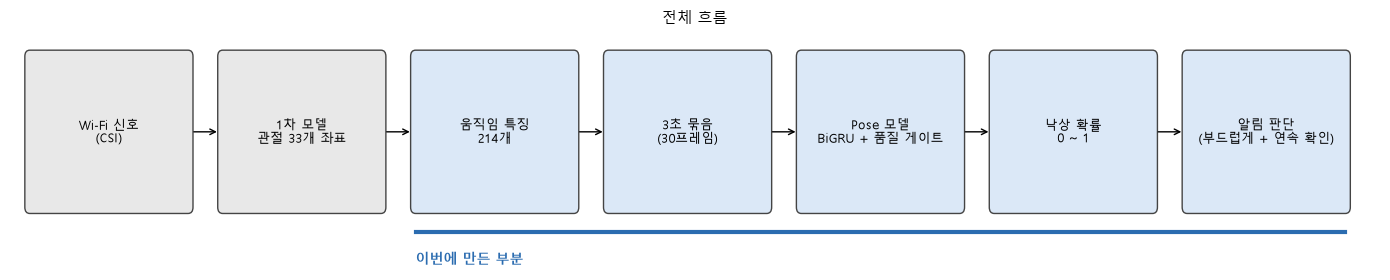

In [2]:
def draw_flow(steps, mark_from, title):
    fig, ax = plt.subplots(figsize=(14, 2.9))
    ax.axis("off")
    w, gap = 1.6, 0.35
    for i, (text, color) in enumerate(steps):
        x = i * (w + gap)
        ax.add_patch(FancyBboxPatch((x, 0.5), w, 1.2, boxstyle="round,pad=0.05", fc=color, ec="#444"))
        ax.text(x + w / 2, 1.1, text, ha="center", va="center", fontsize=9)
        if i < len(steps) - 1:
            ax.annotate("", xy=(x + w + gap - 0.03, 1.1), xytext=(x + w + 0.03, 1.1), arrowprops=dict(arrowstyle="->"))
    x0 = mark_from * (w + gap)
    ax.plot([x0, len(steps) * (w + gap) - gap], [0.3, 0.3], color="#2b6cb0", lw=3)
    ax.text(x0, 0.05, "이번에 만든 부분", color="#2b6cb0", fontsize=10, fontweight="bold")
    ax.set_xlim(-0.2, len(steps) * (w + gap))
    ax.set_ylim(0, 1.9)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

draw_flow([("Wi-Fi 신호\n(CSI)", "#e8e8e8"), ("1차 모델\n관절 33개 좌표", "#e8e8e8"), ("움직임 특징\n214개", "#dbe8f7"),
           ("3초 묶음\n(30프레임)", "#dbe8f7"), ("Pose 모델\nBiGRU + 품질 게이트", "#dbe8f7"), ("낙상 확률\n0 ~ 1", "#dbe8f7"),
           ("알림 판단\n(부드럽게 + 연속 확인)", "#dbe8f7")], 2, "전체 흐름")

### 2.2 단계별 설명

| 단계 | 하는 일 | 자세히 |
|---|---|---|
| 1. 좌표 얻기 | 1차 모델에 CSI를 넣고 뼈대 좌표를 받음 | 0.1초마다 1번(초당 10번), 관절 33개 × (x, y) |
| 2. 특징 만들기 | 좌표를 "움직임"을 보여 주는 숫자로 바꿈 | 아래 표. 프레임마다 214개 |
| 3. 3초 묶음 | 30프레임을 한 덩어리로 묶고 0.5초씩 밀면서 만듦 | 낙상이면 1, 아니면 0인 정답을 붙임 |
| 4. 모델 | 30프레임의 움직임을 읽어 낙상 확률을 냄 | 아래 2.4 |
| 5. 학습 | 정답과 비교하며 모델을 조정 | 낙상이 드물어서(약 3%) 낙상 쪽 오류에 20배 정도 가중치, 3가지 방식으로 데이터를 살짝 변형해서 학습 |
| 6. 알림 판단 | 한 번 높다고 바로 알리지 않음 | 확률을 부드럽게 다듬고, 최근 5번 중 몇 번 이상 높을 때만 알림. 알림 후 5초는 중복 금지 |
| 7. 평가 | 점수와 알림 결과 확인 | 5절 |

### 2.3 특징 214개

| 특징 | 개수 | 뜻 |
|---|---|---|
| 정규화 좌표 | 66 | 엉덩이를 원점으로, 몸 크기로 나눈 관절 위치 (사람이 어디 있든, 얼마나 크든 같은 기준) |
| 속도 | 66 | 관절이 얼마나 빨리 움직이는가 |
| 가속도 | 66 | 움직임이 얼마나 갑자기 변하는가 |
| 엉덩이 위치·속도 | 4 | 화면에서 몸 중심이 어디 있고 얼마나 빨리 이동하는가 |
| 몸통 각도 | 2 | 어깨와 엉덩이를 잇는 선의 기울기 (서 있으면 세로, 누우면 가로) |
| 몸 박스 | 2 | 몸 전체를 감싼 상자의 가로세로 비율과 높이 |
| 뼈 길이 | 8 | 어깨너비, 엉덩이너비, 몸통, 허벅지, 정강이 길이 |
| 합계 | 214 | 이와 별도로 뼈대가 불안정한지 알려 주는 품질 값 7개를 함께 씀 |

### 2.4 모델 안쪽 구조

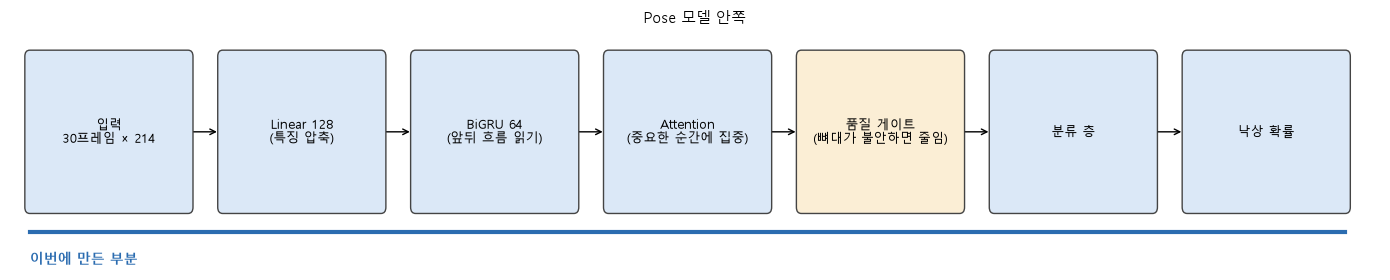

In [3]:
draw_flow([("입력\n30프레임 × 214", "#dbe8f7"), ("Linear 128\n(특징 압축)", "#dbe8f7"), ("BiGRU 64\n(앞뒤 흐름 읽기)", "#dbe8f7"),
           ("Attention\n(중요한 순간에 집중)", "#dbe8f7"), ("품질 게이트\n(뼈대가 불안하면 줄임)", "#fbeed5"), ("분류 층", "#dbe8f7"),
           ("낙상 확률", "#dbe8f7")], 0, "Pose 모델 안쪽")

- **BiGRU**: 시간 순서대로 움직임을 읽는 층입니다. 앞에서 뒤로, 뒤에서 앞으로 두 번 읽습니다.
- **Attention**: 3초 중 낙상과 관련 있는 순간에 더 집중하도록 가중치를 줍니다.
- **품질 게이트**: 뼈대의 흔들림, 뼈 길이 변화 등을 보고 0~1 사이 값을 만들어 곱합니다. 뼈대를 못 믿을 때 Pose의 영향을 줄이는 장치입니다.

### 2.5 정답(라벨)은 이렇게 붙였습니다
사람이 영상을 보고 1초 단위로 붙여 둔 구간 라벨을 사용했습니다.
- `falling` 구간의 앞 0.5초부터 뒤 1.0초까지를 낙상(1)으로 봅니다.
- 서 있음, 낙상 뒤 누워 있음, 일어나는 중, 걷기, 앉기, 물건 줍기 등은 모두 **낙상이 아님(0)** 입니다. 낙상과 헷갈리기 쉬운 동작을 일부러 넣어서 어려운 문제로 만들기 위해서입니다.
- 어느 쪽인지 애매한 window는 학습과 평가에서 뺍니다.

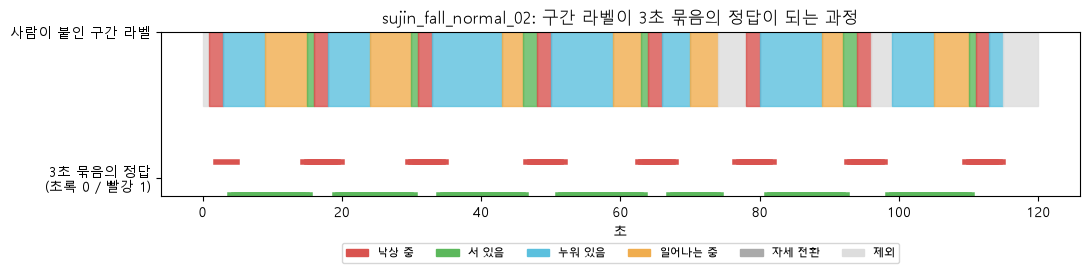

이 녹화에서 만들어진 묶음 166개 (낙상 43개, 낙상 아님 123개), 애매해서 뺀 것 69개


In [4]:
import yaml
from build_pose_windows import build_recording, load_intervals
cfg = yaml.safe_load(open("configs/pose_branch.yaml", encoding="utf-8"))
wcfg = dict(cfg["windows"])
wcfg["post_fall_negatives"] = True
SID = "sujin_fall_normal_02"
iv = load_intervals(Path("../data/labels"))[SID]
z = np.load(f"data/processed/pose_features/v2_oofb_full/{SID}.npz", allow_pickle=True)
feat = {k: z[k] for k in z.files}
rows, meta, excl = build_recording(SID, feat, iv, wcfg, "fall_normal")
mm = pd.DataFrame(meta)
colors = {"falling": "#d9534f", "standing": "#5cb85c", "lying": "#5bc0de", "getting_up": "#f0ad4e", "transition": "#aaaaaa", "ignore": "#dddddd"}
names_ko = {"falling": "낙상 중", "standing": "서 있음", "lying": "누워 있음", "getting_up": "일어나는 중", "transition": "자세 전환", "ignore": "제외"}
fig, ax = plt.subplots(figsize=(11, 3))
for a, b, l in iv:
    ax.axvspan(a, b, ymin=0.55, ymax=1, color=colors.get(l, "#eeeeee"), alpha=0.8)
for r in mm.itertuples():
    ax.plot([r.start_sec, r.end_sec], [0.25 + 0.1 * r.y] * 2, color="#d9534f" if r.y else "#5cb85c", lw=4)
ax.set_yticks([0.3, 0.75])
ax.set_yticklabels(["3초 묶음의 정답\n(초록 0 / 빨강 1)", "사람이 붙인 구간 라벨"])
ax.set_xlabel("초")
ax.set_title(f"{SID}: 구간 라벨이 3초 묶음의 정답이 되는 과정")
ax.legend(handles=[Patch(color=v, label=names_ko[k]) for k, v in colors.items()], ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout()
plt.show()
print(f"이 녹화에서 만들어진 묶음 {len(mm)}개 (낙상 {int(mm.y.sum())}개, 낙상 아님 {int((mm.y == 0).sum())}개), 애매해서 뺀 것 {len(excl)}개")

**해석:**
- **그림의 뜻:** 사람이 붙인 구간 라벨(위 색띠)이 모델이 학습할 정답(아래 선)으로 바뀌는 과정입니다.
- **읽는 법:** 빨간 선(낙상=1)은 낙상 구간 앞뒤에만 생기고, 낙상 뒤 누워 있거나 일어나는 구간은 초록 선(낙상 아님=0)이 됩니다.
- **결론:** 모델은 같은 녹화 안에서 "넘어지는 순간"과 "이미 누워 있는 상태"를 구분해야 합니다. 서 있는 것과 누워 있는 것을 구분하는 것보다 어렵고, 그만큼 실제 상황에 가깝습니다.

## 3. 했던 일

1. **1차 모델을 돌릴 수 있게 만들기.** 1차 모델은 구글 코랩 노트북 안에만 있었고, 저장된 모델 파일(.pt)을 불러서 모든 녹화에 돌려 뼈대를 뽑는 코드가 없었습니다. Pose 모델의 입력이 1차 모델의 출력이라서, 노트북에 있던 모델 구조를 파이썬 코드로 옮겨서 모델 파일을 불러와 돌릴 수 있게 했습니다. 옮긴 코드가 원본과 같은 결과를 내는지도 확인했습니다. 원본 파일은 바꾸지 않았습니다.
2. **좌표 뽑기.** 모든 녹화(178개)에 1차 모델을 돌려서 뼈대 좌표를 초당 10개씩 저장했습니다.
3. **점수가 부풀려지는 문제 해결.** 1차 모델이 학습에 쓴 영상은 정답을 이미 알고 있어서 뼈대가 정답에 가깝게 나옵니다. 그 영상으로 평가하면 점수가 실제보다 높아집니다. 그래서 1차 모델의 **복사본**을 녹화 5묶음으로 나눠 다시 학습해서, 모든 영상의 뼈대를 "처음 보는 영상" 기준으로 만들었습니다. 원본 1차 모델은 바꾸지 않았습니다.
4. **특징, 정답, 3초 묶음 만들기.** (2절)
5. **Pose 모델 학습과 평가.** 초기값을 다르게 해서 3번 반복했습니다.
6. **비교하기.** 같은 방식으로 정답 뼈대와, 따로 만든 1차 모델(carewaveTest)의 뼈대도 넣어 봤습니다.
7. **성능 올리기 시도.** 뼈대 다듬기, 창 길이 바꾸기 등 6가지를 더 해 봤습니다.

## 4. 1차 뼈대 품질과 알림 동작

### 4.1 1차 뼈대는 얼마나 정확한가
정답(MediaPipe)과의 평균 거리(MPJPE)입니다. **같은 1차 모델이라도 학습에 쓴 영상에서는 오차가 작고, 처음 보는 영상에서는 커집니다.** 이것이 3절에서 다시 학습한 이유입니다.

In [8]:
rows = []
for label, d in [("carewaveAI 원본 (학습에 쓴 영상은 정답에 가까움)", "v2"), ("carewaveAI 다시 학습한 것 (모든 영상이 처음 보는 상태)", "v2_oofb"), ("carewaveTest", "cwt")]:
    f = Path("data/pose_predictions") / d / "error_vs_mediapipe.csv"
    if f.exists():
        e = pd.read_csv(f, encoding="utf-8-sig")
        for g, x in e.groupby("first_stage_split"):
            rows.append({"1차 뼈대": label, "그룹": g, "녹화 수": len(x), "오차(MPJPE)": round(x.mpjpe.mean(), 3), "0.05 이내로 맞힌 관절 비율": round(x.pck_005.mean(), 3)})
pd.DataFrame(rows)

,1차 뼈대,그룹,녹화 수,오차(MPJPE),0.05 이내로 맞힌 관절 비율
0,carewaveAI 원본 (학습에 쓴 영상은 정답에 가까움),test,5,0.153,0.141
1,carewaveAI 원본 (학습에 쓴 영상은 정답에 가까움),train,148,0.071,0.506
2,carewaveAI 원본 (학습에 쓴 영상은 정답에 가까움),validation,30,0.106,0.365
3,carewaveAI 다시 학습한 것 (모든 영상이 처음 보는 상태),oof,178,0.115,0.304
4,carewaveTest,test6,6,0.196,0.125
5,carewaveTest,train,159,0.130,0.147
6,carewaveTest,val,12,0.146,0.137


In [9]:
diag = pd.read_csv(R / "trained_model_315/validation_diagnostic.csv", encoding="utf-8-sig")
baseline = float(diag["MPJPE"].iloc[-1])
baseline_pck = float(diag["PCK@0.05"].iloc[-1])
scales = []
for f in Path("data/pose_predictions/gt_diag").glob("*.npz"):
    z = np.load(f, allow_pickle=True)
    scales.append(np.exp(z["pred_log_scale"][z["valid_mask"]]).mean())
print(f"사람 몸 크기(어깨·엉덩이·몸통 기준) 평균: 화면 크기의 약 {np.mean(scales):.2f}")
print(f"아무 정보 없이 평균 자세만 그렸을 때: 오차 {baseline:.3f}, 맞힌 관절 비율 {baseline_pck:.2f}")

사람 몸 크기(어깨·엉덩이·몸통 기준) 평균: 화면 크기의 약 0.31
아무 정보 없이 평균 자세만 그렸을 때: 오차 0.129, 맞힌 관절 비율 0.26


**해석:**
- **오차(MPJPE)의 뜻:** 화면 가로·세로 길이를 1로 했을 때 예측한 관절이 정답에서 평균 얼마나 떨어졌는지입니다. 작을수록 정확합니다. **맞힌 관절 비율(PCK)** 은 정답에서 화면의 5% 이내에 있는 관절의 비율이고 높을수록 좋습니다.
- **비교 기준:** 위 출력처럼 사람 몸 크기는 화면의 약 0.31입니다. 그리고 아무 정보 없이 평균 자세만 그려도 오차가 0.129(맞힌 비율 0.26)입니다. 이보다 충분히 낮아야 1차 모델이 뼈대를 "추정"한다고 할 수 있습니다.
- **지금(carewaveAI):** 학습에 쓴 영상은 오차 0.07(맞힌 비율 0.51)로 정확하지만, 처음 보는 영상은 0.11 ~ 0.15(0.14 ~ 0.37)로 나빠집니다. 다시 학습한 것의 평균 0.115는 몸 크기의 약 3분의 1이 어긋난 값이고, 평균 자세(0.129)보다 겨우 11% 낮습니다.
- **결론:** 학습에 쓴 영상은 뼈대가 정답에 가까워서 그 영상으로 평가하면 점수가 실제보다 좋게 나옵니다. 그래서 모든 영상을 "처음 보는 영상"으로 만들어 평가했습니다. carewaveTest는 학습 세션 0.130, 처음 보는 세션 0.146 ~ 0.196으로 차이가 작습니다.

### 4.2 뼈대의 움직임이 실제로 어떻게 다른가
같은 낙상 녹화(붉은 띠가 낙상 구간)에서 세 가지 뼈대의 **엉덩이 높이, 몸통 기울기(1이면 서 있음, 0에 가까우면 누움), 몸 높이**를 비교합니다. 정답 뼈대는 낙상 순간에 크게 변하는데, 뼈대가 이 변화를 얼마나 담고 있는지가 Pose 모델 성능을 정합니다.

- 속도 = (지금 좌표 − 직전 좌표) ÷ 실제 시간 간격
- 가속도 = 속도의 변화량

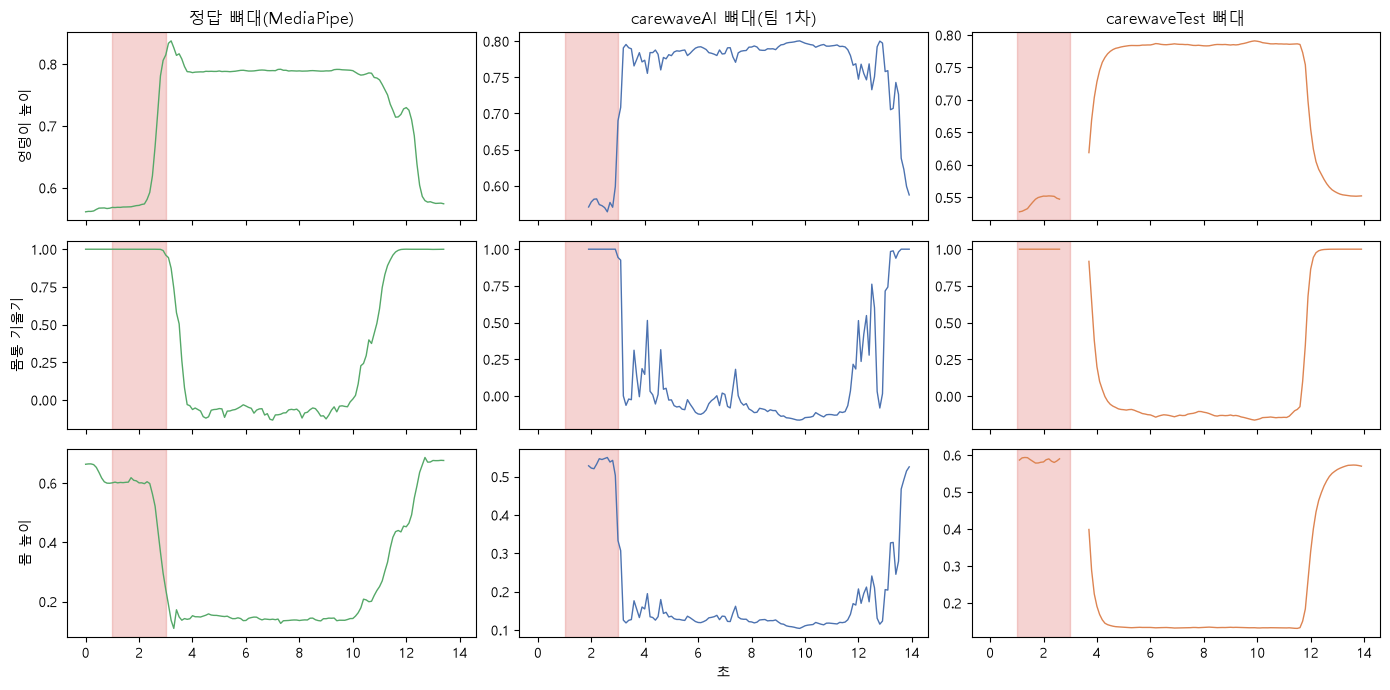

특징 개수: 214 = 좌표 66 + 속도 66 + 가속도 66 + 엉덩이 4 + 몸통각도 2 + 몸박스 2 + 뼈길이 8 = 214


In [10]:
from features.extract_pose_motion_features import extract
SID2 = "yena_fall_normal_11"
iv2 = load_intervals(Path("../data/labels"))[SID2]
fig, axes = plt.subplots(3, 3, figsize=(14, 7), sharex=True)
for j, (label, d) in enumerate([(NAME_GT, "gt_diag"), (NAME_AI, "v2_oofb"), (NAME_TEST, "cwt")]):
    cz = np.load(f"data/pose_predictions/{d}/{SID2}.npz", allow_pickle=True)
    cache = {k: cz[k] for k in cz.files}
    ft = extract(cache, "full")
    names = list(ft["feature_names"])
    t = cache["time_sec"].astype(float)
    v = ft["valid_mask"]
    for i, (key, ko) in enumerate([("pelvis_y", "엉덩이 높이"), ("torso_cos", "몸통 기울기"), ("box_height", "몸 높이")]):
        y = ft["features"][:, names.index(key)].copy()
        y[~v] = np.nan
        axes[i, j].plot(t, y, lw=1, color=COLORS[label])
        for a, b, l in iv2:
            if l == "falling":
                axes[i, j].axvspan(a, b, color="#d9534f", alpha=0.25)
        if i == 0:
            axes[i, j].set_title(label)
        if j == 0:
            axes[i, j].set_ylabel(ko)
axes[-1, 1].set_xlabel("초")
plt.tight_layout()
plt.show()
print("특징 개수:", len(names), "= 좌표 66 + 속도 66 + 가속도 66 + 엉덩이 4 + 몸통각도 2 + 몸박스 2 + 뼈길이 8 =", 66 * 3 + 4 + 2 + 2 + 8)

In [11]:
idx18 = pd.read_csv("data/pose_predictions/cwt/index.csv", encoding="utf-8-sig")
sess18 = sorted(idx18[idx18.first_stage_split.isin(["val", "test6"])].sample_id)

def hip_height(a):
    return 0.5 * (a[:, 23, 1] + a[:, 24, 1])

def body_height(a):
    return a[:, :, 1].max(1) - a[:, :, 1].min(1)

def tracking(cache_dir):
    hips, heights = [], []
    for sid in sess18:
        f = Path("data/pose_predictions") / cache_dir / f"{sid}.npz"
        g = next((R / "synchronized_315").glob(f"*/{sid}_synchronized_315.npz"), None)
        if not f.exists() or g is None:
            continue
        c = np.load(f, allow_pickle=True)
        gt = np.load(g, allow_pickle=True)
        t = gt["csi_time_sec"]
        pos = np.clip(np.searchsorted(c["time_sec"], t), 0, len(c["time_sec"]) - 1)
        ok = c["valid_mask"][pos] & (np.abs(c["time_sec"][pos] - t) < 0.06)
        if ok.sum() < 30:
            continue
        pred, true = c["pred_raw_xy"][pos][ok], gt["pose_xy"][ok]
        for store, fn in ((hips, hip_height), (heights, body_height)):
            x, y = fn(pred), fn(true)
            if x.std() > 1e-6 and y.std() > 1e-6:
                store.append(np.corrcoef(x, y)[0, 1])
    return np.mean(hips), np.mean(heights), len(hips)

rows = []
for name, d in ((NAME_AI, "v2_oofb"), (NAME_TEST, "cwt")):
    h, b, n = tracking(d)
    rows.append({"뼈대": name, "엉덩이 높이 상관": h, "몸 높이 상관": b, "비교한 세션 수": n})
display(pd.DataFrame(rows).set_index("뼈대").round(2))

,엉덩이 높이 상관,몸 높이 상관,비교한 세션 수
뼈대,,,
carewaveAI 뼈대(팀 1차),0.03,0.13,18
carewaveTest 뼈대,0.17,0.17,18


**해석:**
- **그림:** 붉은 띠가 낙상 순간입니다. 정답 뼈대(왼쪽)는 이때 엉덩이 높이와 몸 높이가 크게 변하고, 몸통 기울기가 서 있음(1)에서 누움(0 근처)으로 바뀝니다.
- **상관의 뜻:** 위 표의 숫자는 뼈대가 정답의 엉덩이 높이·몸 높이와 함께 움직이는 정도입니다(-1 ~ 1). 1에 가까우면 정답과 똑같이 움직이고, 0이면 관계가 없습니다.
- **지금:** carewaveAI 0.03(엉덩이)·0.13(몸 높이), carewaveTest 0.17·0.17로 둘 다 0에 가깝습니다. 뼈대가 정답의 움직임을 거의 따라가지 못한다는 뜻입니다.
- **결론:** Pose 모델은 이 움직임을 보고 낙상을 판단합니다. 뼈대에 변화가 담기지 않으면 성능이 나오기 어렵습니다.

### 4.3 낙상 알림 판단이 동작하는 모습
모델이 0.1초마다 낙상 확률을 내면, 바로 알리지 않고 다음을 거칩니다.
1. 확률을 부드럽게 다듬기: $s_t=\alpha\,p_t+(1-\alpha)\,s_{t-1}$
2. 기준값(θ) 이상이면 후보
3. 최근 5번 중 k번 이상 후보이면 알림. 알림 뒤 5초는 다시 알리지 않음

기준값 θ, α, k는 검증 데이터에서만 골랐습니다. 아래 그림에서 **붉은 띠는 실제 낙상 구간, 점선은 알림**입니다.

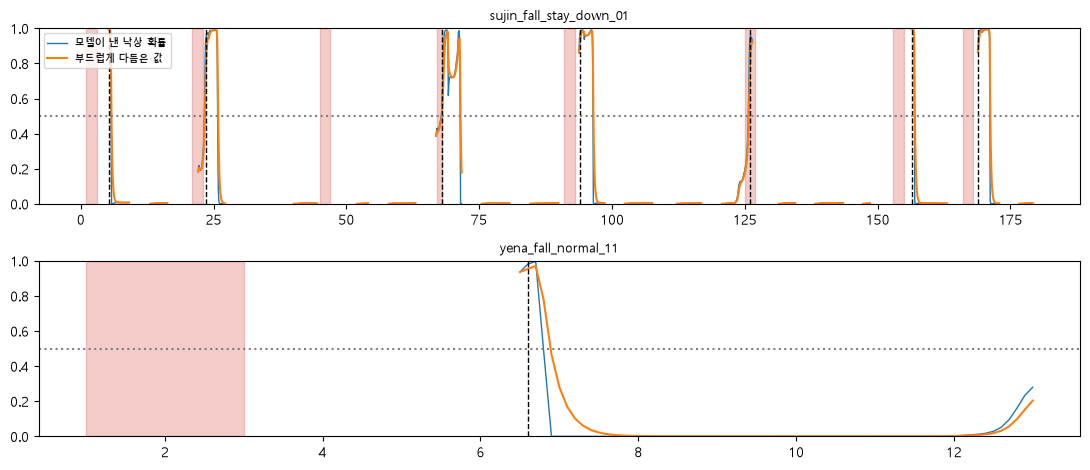

검증에서 정한 값: {'thr': 0.5, 'alpha': 0.4, 'k': 2}


In [14]:
import evaluate_pose_classifier as ev
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
run = OUT / "2_carewaveTest_뼈대" / "seed42"
model, ck, fs, qs = ev.load_run(run)
hashes = json.loads(str(ck["source_hashes"]))
variant, fmode = hashes["variant"], hashes["feature_mode"]
index = pd.read_csv(Path("data/pose_predictions") / variant / "index.csv", encoding="utf-8-sig")
streams = ev.build_streams(model, fs, qs, Path("data/processed/pose_windows") / ck["tag"],
                           Path("data/processed/pose_features") / f"{variant}_{fmode}", "validation", Path("../data/labels"), index, 30)
params = json.load(open(run / "event_params.json"))
show = [s for s in streams if s["events"]][:3]
fig, axes = plt.subplots(len(show), 1, figsize=(11, 2.4 * len(show)), squeeze=False)
for ax, s in zip(axes[:, 0], show):
    ax.plot(s["t"], s["p"], lw=1, label="모델이 낸 낙상 확률")
    sm, st = [], None
    for pi in s["p"]:
        st = np.nan if np.isnan(pi) else (pi if (st is None or np.isnan(st)) else params["alpha"] * pi + (1 - params["alpha"]) * st)
        sm.append(st)
    ax.plot(s["t"], sm, lw=1.5, label="부드럽게 다듬은 값")
    for on, im, pe in s["events"]:
        ax.axvspan(on, im, color="#d9534f", alpha=0.3)
    for a in ev.state_machine(s["p"], s["t"], **params):
        ax.axvline(a, color="k", ls="--", lw=1)
    ax.axhline(params["thr"], color="gray", ls=":")
    ax.set_ylim(0, 1)
    ax.set_title(s["sample_id"], fontsize=9)
axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()
print("검증에서 정한 값:", params)

**해석:**
- **그림 읽는 법:** 파란선은 모델이 0.1초마다 낸 낙상 확률, 굵은 선은 부드럽게 다듬은 값, 가로 점선은 알림 기준값, 붉은 띠는 실제 낙상, 세로 점선은 알림이 울린 시점입니다.
- **좋은 모양:** 붉은 띠 근처에서만 알림이 울리고 다른 곳에서는 울리지 않는 것입니다.
- **지금:** 이 모델의 검증에서 평균 알림 지연은 약 2.8 ~ 3.0초입니다. 연속으로 확인하는 조건 때문에 알림은 낙상이 시작된 뒤 몇 초 늦게 울립니다. 순간적으로 확률이 튀어도 바로 알리지 않아서 오탐이 줄어드는 대신 생기는 지연입니다.

## 5. 성능 평가

### 5.1 같은 세션 18개로 세 가지 뼈대를 공정하게 비교
평가한 세션이 다르면 비교가 불공정하므로, **carewaveTest 모델이 학습에 쓰지 않은 18개 세션**을 세 뼈대 모두에게 똑같이 시험 문제로 냈습니다. Pose 모델은 나머지 녹화로 학습했고(GBM), 결과를 보고 조정하지 않았습니다.

95% 범위는 세션을 무작위로 다시 뽑아 300번 반복해서 구한 값입니다. **범위가 넓을수록 표본이 적어서 점수가 흔들린다**는 뜻입니다.

In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
W = Path("data/processed/pose_windows")
idx = pd.read_csv("data/pose_predictions/cwt/index.csv", encoding="utf-8-sig")
unseen = set(idx[idx.first_stage_split.isin(["val", "test6"])].sample_id)
TAGS = {NAME_AI: "v2_oofb_full_stratified_pfn", NAME_TEST: "cwt_full_lineage_oos_pfn", NAME_GT: "gt_diag_full_stratified_pfn"}

def load_all(tag):
    parts = [np.load(W / tag / f"{s}_3s.npz", allow_pickle=True) for s in ("train", "validation", "test") if (W / tag / f"{s}_3s.npz").exists()]
    return {k: np.concatenate([p[k] for p in parts]) for k in ("X_pose", "y", "sample_id", "subtype")}

def stats(X):
    return np.concatenate([X.mean(1), X.std(1), np.ptp(X, axis=1)], axis=1)

PRED = {}
for name, tag in TAGS.items():
    d = load_all(tag)
    te = np.isin(d["sample_id"], list(unseen))
    gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.06, max_iter=80, class_weight="balanced", random_state=0)
    gbm.fit(stats(d["X_pose"][~te]), d["y"][~te])
    PRED[name] = {"p": gbm.predict_proba(stats(d["X_pose"][te]))[:, 1], "y": d["y"][te], "g": d["sample_id"][te], "sub": d["subtype"][te]}

def session_ci(p, y, g, n=300, seed=0):
    rng = np.random.default_rng(seed)
    ids = np.unique(g)
    by = {i: np.where(g == i)[0] for i in ids}
    a, b = [], []
    for _ in range(n):
        ix = np.concatenate([by[i] for i in rng.choice(ids, len(ids))])
        if y[ix].sum() == 0 or y[ix].sum() == len(ix):
            continue
        a.append(roc_auc_score(y[ix], p[ix]))
        b.append(average_precision_score(y[ix], p[ix]))
    return np.percentile(a, [2.5, 97.5]), np.percentile(b, [2.5, 97.5])

rows = []
for name, r in PRED.items():
    ca, cb = session_ci(r["p"], r["y"], r["g"])
    rows.append({"뼈대": name, "낙상 window": int(r["y"].sum()), "전체 window": len(r["y"]),
                 "AUROC": roc_auc_score(r["y"], r["p"]), "AUROC 95% 범위": f"{ca[0]:.2f} ~ {ca[1]:.2f}",
                 "AUPRC": average_precision_score(r["y"], r["p"]), "AUPRC 95% 범위": f"{cb[0]:.2f} ~ {cb[1]:.2f}",
                 "찍기 수준 AUPRC": float(r["y"].mean())})
fair = pd.DataFrame(rows).set_index("뼈대")
display(fair.round(3))

,낙상 window,전체 window,AUROC,AUROC 95% 범위,AUPRC,AUPRC 95% 범위,찍기 수준 AUPRC
뼈대,,,,,,,
carewaveAI 뼈대(팀 1차),80,3033,0.766,0.57 ~ 0.97,0.054,0.01 ~ 0.33,0.026
carewaveTest 뼈대,39,1840,0.944,0.88 ~ 1.00,0.359,0.08 ~ 1.00,0.021
정답 뼈대(MediaPipe),80,3057,0.997,0.99 ~ 1.00,0.970,0.95 ~ 1.00,0.026


**해석:**
- **AUROC의 뜻과 지금:** 정답 뼈대 0.997은 거의 완벽, carewaveTest 0.94는 잘 구분, carewaveAI 0.77은 0.5(동전 던지기)보다는 높지만 0.9(잘 구분)에는 못 미치는 "약함"입니다.
- **AUPRC의 뜻과 지금:** 낙상이 드물어서(약 2.6%) 찍으면 0.03 안팎이 나옵니다. 정답 0.97, carewaveTest 0.36(찍기의 약 17배), carewaveAI 0.05(찍기의 약 2배)입니다.
- **95% 범위의 뜻:** 같은 실험을 다시 했을 때 점수가 움직일 것으로 보이는 범위입니다. carewaveAI의 AUROC 범위(0.57 ~ 0.97)가 carewaveTest의 범위(0.88 ~ 1.00)와 겹칩니다. 그래서 "carewaveTest가 더 낫다"는 경향은 보이지만 세션 18개로는 확정할 수 없습니다.
- **결론:** 확실한 것은 정답 뼈대가 두 1차 뼈대보다 훨씬 좋다는 점입니다. 범위를 좁히려면 낙상이 더 많이 든 새 녹화가 필요합니다.

### 5.2 ROC 곡선과 PR 곡선
- **ROC 곡선**: 왼쪽 위로 붙을수록 좋습니다. 대각선(점선)은 동전 던지기입니다.
- **PR 곡선**: 오른쪽 위로 붙을수록 좋습니다. 점선은 아무렇게나 찍었을 때의 수준입니다.

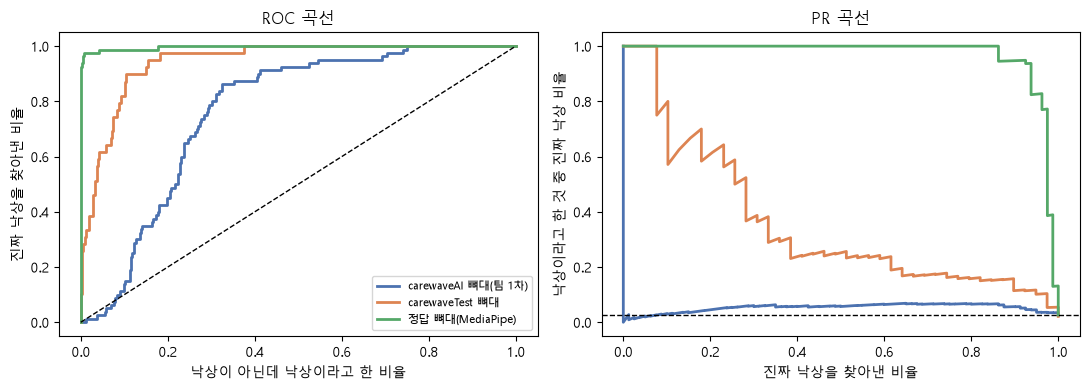

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, r in PRED.items():
    fpr, tpr, _ = roc_curve(r["y"], r["p"])
    axes[0].plot(fpr, tpr, label=name, color=COLORS[name], lw=2)
    pr, rc, _ = precision_recall_curve(r["y"], r["p"])
    axes[1].plot(rc, pr, label=name, color=COLORS[name], lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("낙상이 아닌데 낙상이라고 한 비율")
axes[0].set_ylabel("진짜 낙상을 찾아낸 비율")
axes[0].set_title("ROC 곡선")
axes[1].axhline(float(np.mean([r["y"].mean() for r in PRED.values()])), color="k", ls="--", lw=1)
axes[1].set_xlabel("진짜 낙상을 찾아낸 비율")
axes[1].set_ylabel("낙상이라고 한 것 중 진짜 낙상 비율")
axes[1].set_title("PR 곡선")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
rows = []
for name, r in PRED.items():
    fpr, tpr, _ = roc_curve(r["y"], r["p"])
    pr, rc, _ = precision_recall_curve(r["y"], r["p"])
    rows.append({"뼈대": name, "오판 5% 허용 시 찾은 낙상 비율": tpr[fpr <= 0.05].max(), "오판 10% 허용 시": tpr[fpr <= 0.10].max(),
                 "오판 20% 허용 시": tpr[fpr <= 0.20].max(), "낙상의 절반을 찾을 때 알림 정확도": pr[rc >= 0.5].max()})
display(pd.DataFrame(rows).set_index("뼈대").round(2))

,오판 5% 허용 시 찾은 낙상 비율,오판 10% 허용 시,오판 20% 허용 시,낙상의 절반을 찾을 때 알림 정확도
뼈대,,,,
carewaveAI 뼈대(팀 1차),0.02,0.14,0.45,0.07
carewaveTest 뼈대,0.62,0.82,0.97,0.26
정답 뼈대(MediaPipe),0.99,0.99,1.00,1.00


**해석:**
- **ROC 곡선의 뜻:** 낙상이 아닌 것을 낙상이라고 오판하는 비율을 조금씩 늘려 갈 때, 진짜 낙상을 얼마나 더 찾는지입니다. 왼쪽 위로 붙을수록 좋고 대각선은 동전 던지기입니다.
- **PR 곡선의 뜻:** 낙상을 더 많이 찾으려 할수록 "낙상이라고 한 것 중 진짜 낙상 비율(정확도)"이 얼마나 떨어지는지입니다. 오른쪽 위로 붙을수록 좋습니다.
- **지금(위 표):** 오판을 10%까지 허용했을 때 찾은 낙상 비율은 정답 99%, carewaveTest 82%, carewaveAI **14%** 입니다. 낙상의 절반을 찾으려 할 때 알림의 정확도는 정답 100%, carewaveTest 26%, carewaveAI **7%** 입니다. 7%는 알림 100번 중 93번이 잘못된 알림이라는 뜻입니다.
- **결론:** carewaveAI 뼈대는 이 조건에서 실제로 쓰기 어렵습니다. carewaveTest는 가능성이 보이지만 오탐이 많습니다.

### 5.3 모델이 낸 점수의 분포
낙상 window(빨강)의 점수는 오른쪽(높은 쪽), 나머지(회색)는 왼쪽에 몰려야 좋습니다. **두 색이 겹칠수록 구분이 어렵습니다.**

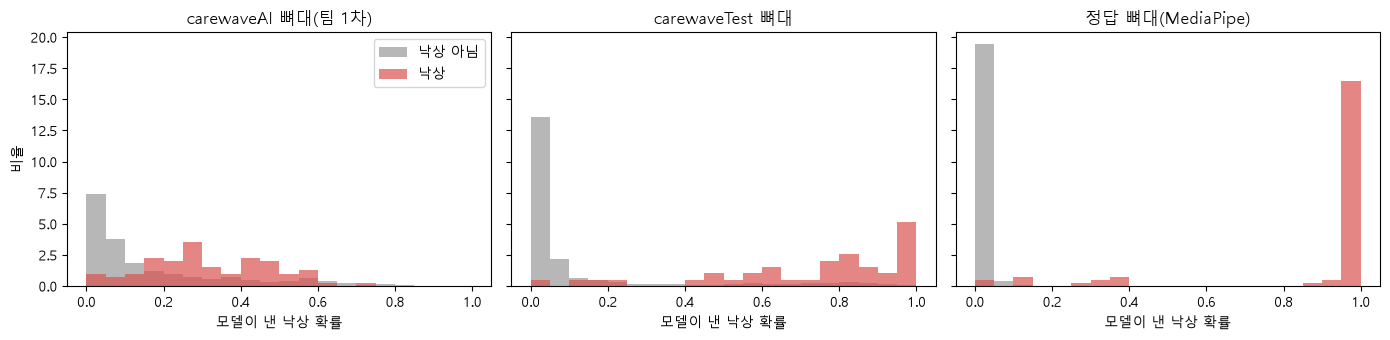

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (name, r) in zip(axes, PRED.items()):
    bins = np.linspace(0, 1, 21)
    ax.hist(r["p"][r["y"] == 0], bins=bins, density=True, color="#999999", alpha=0.7, label="낙상 아님")
    ax.hist(r["p"][r["y"] == 1], bins=bins, density=True, color="#d9534f", alpha=0.7, label="낙상")
    ax.set_title(name)
    ax.set_xlabel("모델이 낸 낙상 확률")
axes[0].set_ylabel("비율")
axes[0].legend()
plt.tight_layout()
plt.show()

In [19]:
rows = []
for name, r in PRED.items():
    y, p = r["y"], r["p"]
    rows.append({"뼈대": name, "낙상 조각의 중앙값": np.median(p[y == 1]), "낙상 아닌 조각의 중앙값": np.median(p[y == 0]),
                 "낙상 중 0.5 넘은 비율": np.mean(p[y == 1] >= 0.5), "낙상 아닌 것 중 0.5 넘은 비율": np.mean(p[y == 0] >= 0.5)})
display(pd.DataFrame(rows).set_index("뼈대").round(2))

,낙상 조각의 중앙값,낙상 아닌 조각의 중앙값,낙상 중 0.5 넘은 비율,낙상 아닌 것 중 0.5 넘은 비율
뼈대,,,,
carewaveAI 뼈대(팀 1차),0.28,0.08,0.14,0.1
carewaveTest 뼈대,0.81,0.03,0.82,0.1
정답 뼈대(MediaPipe),0.99,0.01,0.86,0.0


**해석:**
- **그림·표의 뜻:** 모델이 조각마다 준 낙상 확률의 분포입니다. 낙상 조각(빨강)은 1 가까이, 낙상이 아닌 조각(회색)은 0 가까이로 갈라져야 좋습니다. 두 색이 겹칠수록 구분이 어렵습니다.
- **좋은 값:** 낙상 조각의 중앙값은 높고(0.8 이상), 낙상 아닌 조각의 중앙값은 낮아야(0.1 이하) 합니다. 확률 0.5를 기준으로 삼았을 때 낙상 중 넘는 비율은 높고, 낙상 아닌 것 중 넘는 비율은 낮아야 합니다.
- **지금:** 정답은 0.99 대 0.01, carewaveTest는 0.81 대 0.03으로 잘 갈립니다. carewaveAI는 0.28 대 0.08로 겹칩니다. 기준 0.5에서 carewaveAI는 낙상의 14%만 넘고, 낙상이 아닌 것도 10%가 넘습니다. 즉 구분이 안 됩니다.

### 5.4 어떤 동작을 낙상으로 착각하는가
동작 종류별로 모델이 낸 낙상 확률의 평균입니다. **낙상(맨 위)만 높고 나머지는 낮아야 좋습니다.** 낙상과 비슷하게 높게 나오는 동작이 오탐의 원인입니다.

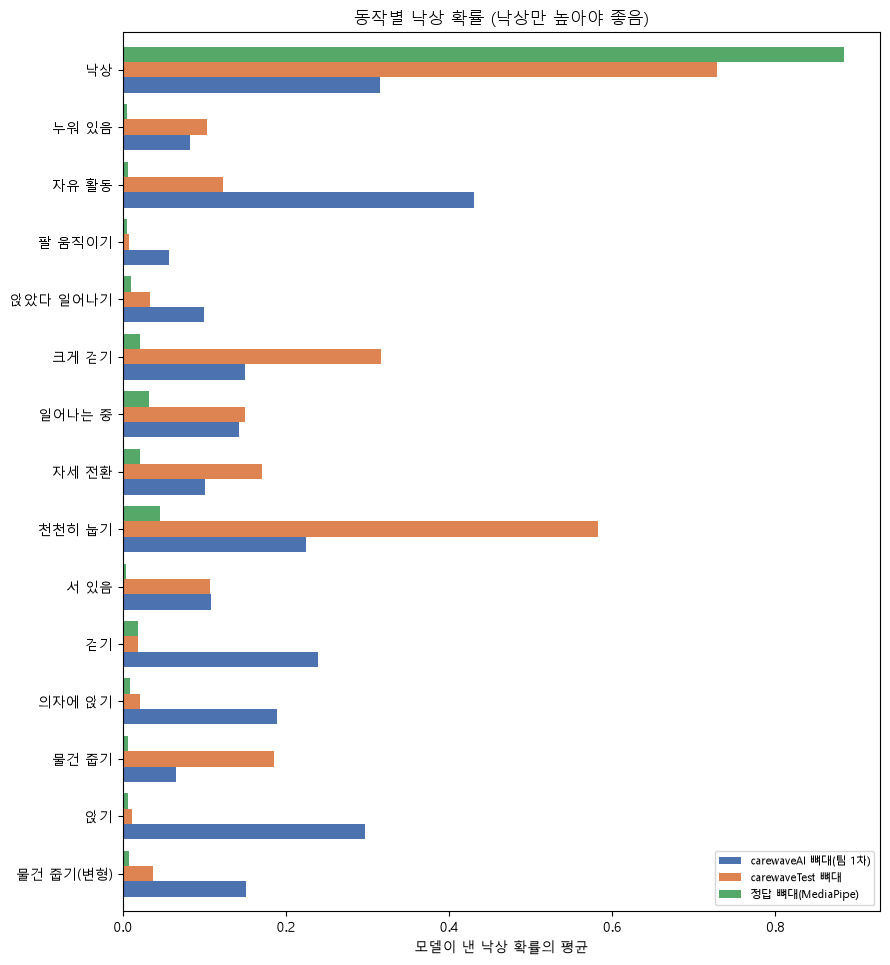

In [20]:
ko = {"fall": "낙상", "standing": "서 있음", "lying": "누워 있음", "getting_up": "일어나는 중", "transition": "자세 전환",
      "slow_lying_down": "천천히 눕기", "walk_normal": "걷기", "walk_large_motion": "크게 걷기", "sit_normal": "앉기",
      "sit_to_stand_normal": "앉았다 일어나기", "chair_sit_variation": "의자에 앉기", "pick_up_normal": "물건 줍기",
      "pick_up_variation": "물건 줍기(변형)", "bending_normal": "허리 숙이기", "free_activity_normal": "자유 활동",
      "free_activity": "자유 활동", "arm_move_normal": "팔 움직이기", "sit_move_normal": "앉아서 움직이기"}
first = PRED[NAME_GT]
counts = pd.Series(first["sub"]).value_counts()
keep = [k for k in counts.index if counts[k] >= 15]
tab = pd.DataFrame({name: pd.Series(r["p"]).groupby(r["sub"]).mean() for name, r in PRED.items()}).loc[keep]
tab = tab.loc[["fall"] + [k for k in tab.index if k != "fall"]]
tab.index = [ko.get(k, k) for k in tab.index]
tab[::-1].plot.barh(figsize=(9, 0.55 * len(tab) + 1.5), color=[COLORS[c] for c in tab.columns], width=0.8)
plt.xlabel("모델이 낸 낙상 확률의 평균")
plt.title("동작별 낙상 확률 (낙상만 높아야 좋음)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
cnt = pd.Series(first["sub"]).value_counts()
shown = pd.DataFrame({name: pd.Series(r["p"]).groupby(r["sub"]).mean() for name, r in PRED.items()}).loc[keep]
shown = shown.loc[["fall"] + [k for k in shown.index if k != "fall"]]
shown["조각 수"] = [int(cnt[k]) for k in shown.index]
shown.index = [ko.get(k, k) for k in shown.index]
display(shown.round(2))

,carewaveAI 뼈대(팀 1차),carewaveTest 뼈대,정답 뼈대(MediaPipe),조각 수
낙상,0.32,0.73,0.88,80
누워 있음,0.08,0.10,0.01,873
자유 활동,0.43,0.12,0.01,596
팔 움직이기,0.06,0.01,0.01,357
앉았다 일어나기,0.10,0.03,0.01,356
크게 걷기,0.15,0.32,0.02,355
일어나는 중,0.14,0.15,0.03,157
자세 전환,0.10,0.17,0.02,72
천천히 눕기,0.23,0.58,0.05,61
서 있음,0.11,0.11,0.00,49


**해석:**
- **표·그림의 뜻:** 동작 종류별로 모델이 준 낙상 확률의 평균입니다. 진짜 낙상(맨 위)만 높고 나머지는 낮아야 합니다. 낙상과 비슷하게 높은 동작이 오탐의 원인입니다.
- **좋은 값:** 낙상은 0.7 이상, 나머지는 0.1 이하입니다.
- **지금:** carewaveAI는 자유 활동 0.43, 앉기 0.30, 걷기 0.24로 낙상(0.32)과 비슷하거나 더 높습니다. carewaveTest는 천천히 눕기 0.58, 크게 걷기 0.32를 낙상(0.73)과 헷갈립니다. 정답 뼈대는 낙상 0.88만 높고 나머지는 0.05 이하입니다.
- **주의:** 걷기, 앉기, 줍기는 조각이 20개 안팎이라 참고만.

### 5.5 Pose 신경망 결과 (3번 반복, 검증과 TEST)
초기값을 다르게 해서 3번 학습했습니다(seed 42, 43, 44). 기준값은 **검증에서만** 정하고, TEST는 그 값 그대로 **딱 한 번** 평가했습니다.

**표를 읽을 때 주의:** TEST에는 낙상이 7~28개뿐이라 seed마다 점수가 크게 달라집니다. 특히 carewaveAI 뼈대의 TEST AUROC는 0.63에서 0.99까지 흔들립니다. 이 숫자 하나로 "잘 된다/안 된다"를 판단할 수 없고, 5.1의 범위와 함께 봐야 합니다.

In [22]:
rows = []
for folder, label in RUNS.items():
    for seed in (42, 43, 44):
        for split, fname in (("검증", "val_metrics.json"), ("TEST", "test_metrics.json")):
            f = OUT / folder / f"seed{seed}" / fname
            if not f.exists():
                continue
            m = json.loads(f.read_text(encoding="utf-8"))
            w, e = m["window"], m["event"]
            rows.append({"뼈대": label, "평가": split, "seed": seed, "낙상 window 수": w["n_fall"], "AUROC": w["auroc"], "AUPRC": w["auprc"],
                         "낙상 재현율": w["recall"], "특이도": w["specificity"], "이벤트 재현율": f'{e["matched"]}/{e["events"]}',
                         "이벤트 재현율(값)": e["event_recall"], "시간당 오탐": e["false_alarms_per_hour"], "알림 지연(초)": e["mean_latency_sec"]})
res = pd.DataFrame(rows)
display(res.drop(columns=["이벤트 재현율(값)"]).round(3))
summ = res.groupby(["뼈대", "평가"])[["AUROC", "AUPRC", "이벤트 재현율(값)", "시간당 오탐", "알림 지연(초)"]].agg(["mean", "std"]).round(3)
print("3번 반복의 평균과 표준편차")
display(summ)

,뼈대,평가,seed,낙상 window 수,AUROC,AUPRC,낙상 재현율,특이도,이벤트 재현율,시간당 오탐,알림 지연(초)
0,carewaveAI 뼈대(팀 1차),검증,42,46,0.587,0.056,0.326,0.905,5/13,67.941,4.000
1,carewaveAI 뼈대(팀 1차),TEST,42,7,0.987,0.126,0.857,0.973,6/7,18.927,3.667
2,carewaveAI 뼈대(팀 1차),검증,43,46,0.669,0.040,0.522,0.735,11/13,365.180,2.536
3,carewaveAI 뼈대(팀 1차),TEST,43,7,0.958,0.035,0.857,0.922,5/7,101.735,3.400
4,carewaveAI 뼈대(팀 1차),검증,44,46,0.752,0.109,0.630,0.740,12/13,445.860,2.767
5,carewaveAI 뼈대(팀 1차),TEST,44,7,0.627,0.005,0.286,0.854,3/7,269.716,3.333
6,carewaveTest 뼈대,검증,42,19,1.000,1.000,0.895,1.000,8/9,0.000,2.962
7,carewaveTest 뼈대,TEST,42,20,0.919,0.263,0.700,0.914,4/8,99.049,2.275
8,carewaveTest 뼈대,검증,43,19,1.000,1.000,1.000,1.000,8/9,0.000,2.850
9,carewaveTest 뼈대,TEST,43,20,0.951,0.277,1.000,0.816,7/8,104.709,1.629


3번 반복의 평균과 표준편차


AUROC         AUPRC        이벤트 재현율(값)         \
                           mean    std   mean    std       mean    std   
뼈대                  평가                                                   
carewaveAI 뼈대(팀 1차) TEST  0.857  0.200  0.055  0.063      0.667  0.218   
                    검증    0.669  0.083  0.068  0.036      0.718  0.291   
carewaveTest 뼈대     TEST  0.942  0.020  0.295  0.045      0.667  0.191   
                    검증    1.000  0.000  1.000  0.000      0.889  0.000   
정답 뼈대(MediaPipe)    TEST  1.000  0.000  1.000  0.000      1.000  0.000   
                    검증    1.000  0.000  1.000  0.001      1.000  0.000   

                           시간당 오탐          알림 지연(초)         
                             mean      std     mean    std  
뼈대                  평가                                      
carewaveAI 뼈대(팀 1차) TEST  130.126  127.782    3.467  0.176  
                    검증    292.994  199.033    3.101  0.787  
carewaveTest 뼈대     TEST  105.652    7.122    2.048  0.364  
                    검증      0.000    0.000    2.867  0.089  
정답 뼈대(MediaPipe)    TEST    7.905    3.623    1.715  0.000  
                    검증      0.000    0.000    1.480  0.141

**해석:**
- **읽는 법:** TEST(처음 보는 데이터, 3번 반복 평균) 기준입니다.
- **정답 뼈대:** AUROC 1.00, 이벤트 재현율 1.0(사건 7개를 모두 알림, 목표 0.9 충족), 알림 지연 1.7초, 시간당 오탐 약 8건(목표 1건 미만은 미달). 잘 동작하지만 오탐이 남습니다.
- **carewaveTest:** AUROC 0.94, 이벤트 재현율 0.67(목표 미달), 시간당 오탐 약 106건(약 34초에 한 번 잘못 울림). 구분은 하지만 놓치는 사건이 있고 오탐이 많습니다.
- **carewaveAI:** AUROC 평균 0.86이지만 반복마다 0.63 ~ 0.99로 크게 흔들리고, 이벤트 재현율 0.67, 시간당 오탐 약 130건입니다. 결과가 불안정해서 믿기 어렵습니다.
- **주의:** 검증에서 1.0이 나오는 것은 검증 낙상이 19개뿐이기 때문입니다. TEST가 더 현실적입니다.

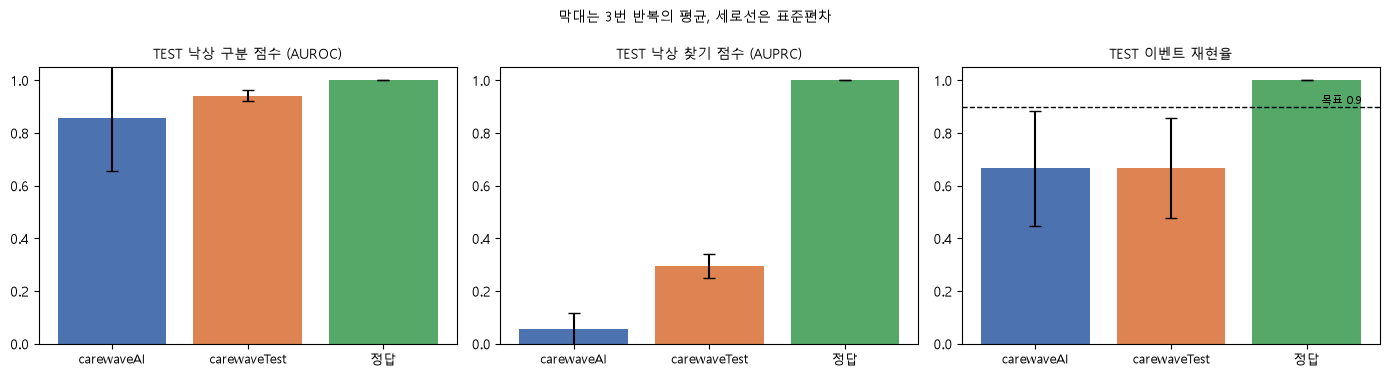

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
test = res[res["평가"] == "TEST"]
for ax, col, title in zip(axes, ["AUROC", "AUPRC", "이벤트 재현율(값)"], ["TEST 낙상 구분 점수 (AUROC)", "TEST 낙상 찾기 점수 (AUPRC)", "TEST 이벤트 재현율"]):
    g = test.groupby("뼈대")[col].agg(["mean", "std"]).loc[list(RUNS.values())]
    ax.bar(range(3), g["mean"], yerr=g["std"].fillna(0), color=[COLORS[n] for n in g.index], capsize=4)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["carewaveAI", "carewaveTest", "정답"], fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 1.05)
axes[2].axhline(0.9, color="k", ls="--", lw=1)
axes[2].text(2.4, 0.91, "목표 0.9", fontsize=8, ha="right")
plt.suptitle("막대는 3번 반복의 평균, 세로선은 표준편차", fontsize=10)
plt.tight_layout()
plt.show()

**해석:** 막대는 3번 반복의 평균이고 세로선은 표준편차(결과가 흔들린 정도)입니다. 세로선이 짧을수록 안정적입니다. 이벤트 재현율(오른쪽)은 정답 뼈대만 목표선(0.9)을 넘습니다. carewaveAI는 AUROC 세로선이 길어서(표준편차 0.2) 같은 조건에서 학습을 반복해도 결과가 크게 달라진다는 뜻이고, 그래서 신뢰하기 어렵습니다.

### 5.6 TEST 결과 그림 (seed 42)
왼쪽은 맞고 틀린 개수(혼동행렬), 오른쪽은 시간에 따른 낙상 확률입니다. 붉은 띠는 실제 낙상 구간, 점선은 알림입니다.

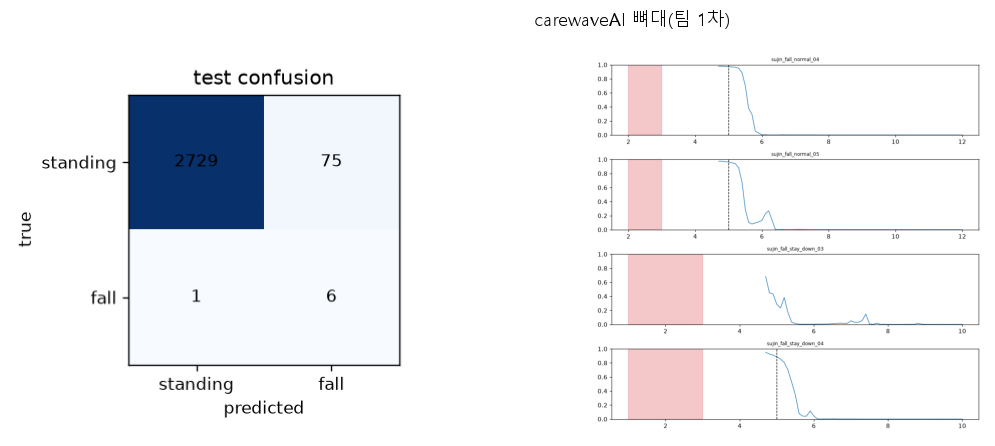

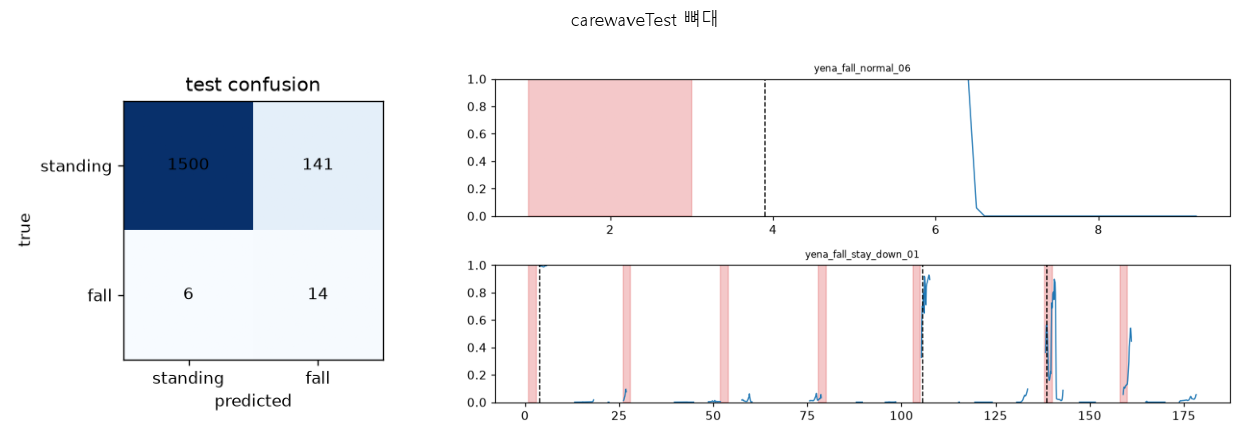

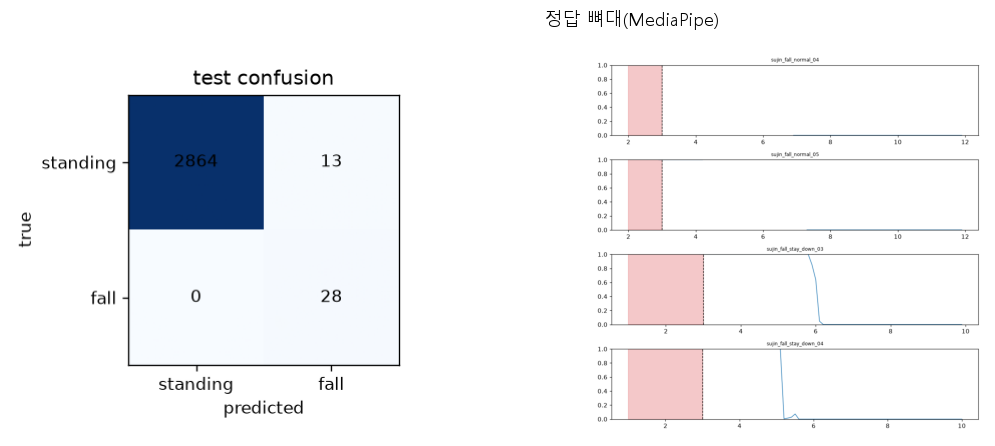

In [24]:
for folder, label in RUNS.items():
    a = OUT / folder / "seed42" / "confusion_matrix_test.png"
    b = OUT / folder / "seed42" / "event_timeline_test.png"
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 2.2]})
    for ax, f in zip(axes, (a, b)):
        ax.axis("off")
        if f.exists():
            ax.imshow(plt.imread(f))
    fig.suptitle(label, fontsize=13)
    plt.tight_layout()
    plt.show()

In [25]:
rows = []
for folder, label in RUNS.items():
    m = json.loads((OUT / folder / "seed42" / "test_metrics.json").read_text(encoding="utf-8"))
    (tn, fp), (fn, tp) = m["window"]["confusion"]
    rows.append({"뼈대": label, "낙상을 찾음(TP)": tp, "낙상을 놓침(FN)": fn, "잘못된 낙상 알림(FP)": fp, "낙상 아님을 맞힘(TN)": tn})
display(pd.DataFrame(rows).set_index("뼈대"))

,낙상을 찾음(TP),낙상을 놓침(FN),잘못된 낙상 알림(FP),낙상 아님을 맞힘(TN)
뼈대,,,,
carewaveAI 뼈대(팀 1차),6,1,75,2729
carewaveTest 뼈대,14,6,141,1500
정답 뼈대(MediaPipe),28,0,13,2864


**해석:**
- **혼동행렬 읽는 법:** 왼쪽 위는 낙상 아님을 맞힘(TN), 오른쪽 아래는 낙상을 찾음(TP), 오른쪽 위는 잘못된 낙상 알림(FP, 오탐), 왼쪽 아래는 놓친 낙상(FN)입니다. 오른쪽 위와 왼쪽 아래가 작을수록 좋습니다.
- **지금(위 표, seed 42):** carewaveAI는 낙상 7개 중 6개를 찾고 낙상이 아닌 2,804개 중 75개(2.7%)를 낙상으로 오판했습니다. carewaveTest는 20개 중 14개를 찾고 1,641개 중 141개(8.6%)를 오판했습니다. 정답 뼈대는 28개를 모두 찾고 2,877개 중 13개(0.5%)를 오판했습니다. 오판 비율은 작아 보여도, 낙상이 드물어서 알림의 상당수가 잘못된 알림이 됩니다.
- **타임라인:** 이 TEST 녹화는 낙상이 녹화 맨 앞(1 ~ 3초)에 있고, 1차 뼈대는 약 4.7초부터 나옵니다. 그래서 첫 예측 시점에는 낙상이 이미 지나 있어 확률이 처음부터 높게 시작해 내려가고, 알림이 낙상이 끝난 뒤 2 ~ 3초에 울립니다. 알림 지연은 모델보다 3초 창 구조의 영향이 큽니다.

### 5.7 학습이 잘 되었는가 (학습 곡선, seed 42)
학습 오차(왼쪽)가 내려가는데 검증 점수(오른쪽)가 함께 오르지 않으면, 학습한 영상에만 맞추고 있다는 뜻입니다.

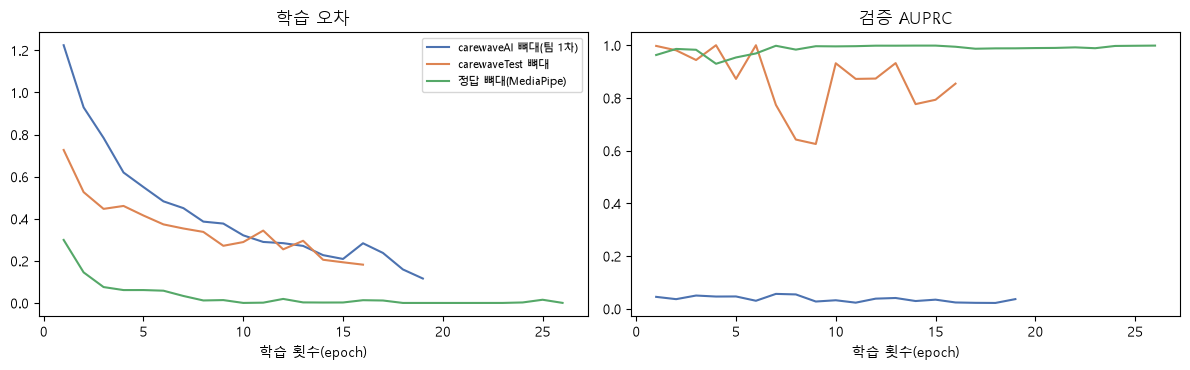

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for folder, label in RUNS.items():
    h = pd.read_csv(OUT / folder / "seed42" / "history.csv")
    axes[0].plot(h.epoch, h.train_loss, label=label, color=COLORS[label])
    axes[1].plot(h.epoch, h.val_auprc, label=label, color=COLORS[label])
axes[0].set_title("학습 오차")
axes[1].set_title("검증 AUPRC")
for ax in axes:
    ax.set_xlabel("학습 횟수(epoch)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
rows = []
for folder, label in RUNS.items():
    h = pd.read_csv(OUT / folder / "seed42" / "history.csv")
    rows.append({"뼈대": label, "학습 횟수": len(h), "학습 오차(처음)": h.train_loss.iloc[0], "학습 오차(마지막)": h.train_loss.iloc[-1],
                 "검증 AUPRC 최고": h.val_auprc.max(), "최고였던 회차": int(h.val_auprc.idxmax()) + 1, "검증 AUPRC 마지막": h.val_auprc.iloc[-1]})
display(pd.DataFrame(rows).set_index("뼈대").round(2))

,학습 횟수,학습 오차(처음),학습 오차(마지막),검증 AUPRC 최고,최고였던 회차,검증 AUPRC 마지막
뼈대,,,,,,
carewaveAI 뼈대(팀 1차),19,1.22,0.12,0.06,7,0.04
carewaveTest 뼈대,16,0.73,0.18,1.00,4,0.85
정답 뼈대(MediaPipe),26,0.30,0.00,1.00,14,1.00


**해석:**
- **곡선의 뜻:** 왼쪽은 학습 오차(모델이 학습 데이터를 얼마나 틀리는지, 작을수록 좋음), 오른쪽은 검증 AUPRC(처음 보는 데이터에서 낙상을 찾는 점수, 높을수록 좋음)입니다.
- **좋은 모양:** 학습 오차가 내려가면서 검증 점수도 함께 올라야 합니다. 학습 오차만 내려가고 검증 점수가 오르지 않으면 학습 영상만 외우는 과적합입니다.
- **지금(위 표):** carewaveAI는 학습 오차가 1.22에서 0.12로 크게 내려가는데 검증 AUPRC는 7번째에 최고 0.06이고 이후 오르지 않습니다(과적합). carewaveTest는 4번째에 1.0까지 올랐다가 마지막에 0.85로 조금 내려갑니다. 정답은 14번째에 0.999로 최고입니다.
- **참고:** 모든 모델은 검증 점수가 최고일 때의 모델을 저장해서 씁니다.

### 5.8 낙상 알림 결과와 설계서 목표
막대가 목표선을 넘어야 합니다. 이벤트 재현율은 **위쪽 선(0.9) 이상**, 시간당 오탐은 **아래쪽 선(1건) 이하**여야 합니다.

시간당 오탐은 낙상이 아닌 시간이 TEST 전체에서 25분 남짓뿐이라 값이 크게 흔들립니다.

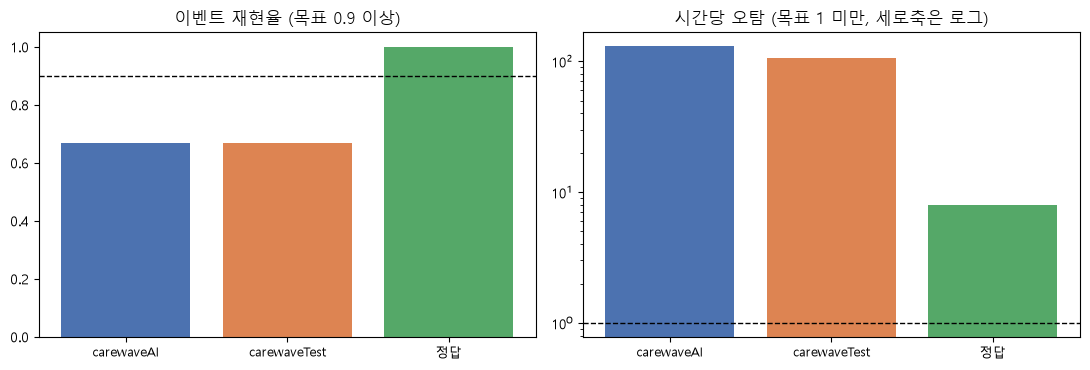

,이벤트 재현율(값),시간당 오탐,알림 지연(초)
뼈대,,,
carewaveAI 뼈대(팀 1차),0.67,130.13,3.47
carewaveTest 뼈대,0.67,105.65,2.05
정답 뼈대(MediaPipe),1.00,7.91,1.71


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
g = test.groupby("뼈대")[["이벤트 재현율(값)", "시간당 오탐"]].mean().loc[list(RUNS.values())]
axes[0].bar(range(3), g["이벤트 재현율(값)"], color=[COLORS[n] for n in g.index])
axes[0].axhline(0.9, color="k", ls="--", lw=1)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("이벤트 재현율 (목표 0.9 이상)")
axes[1].bar(range(3), g["시간당 오탐"], color=[COLORS[n] for n in g.index])
axes[1].axhline(1, color="k", ls="--", lw=1)
axes[1].set_yscale("log")
axes[1].set_title("시간당 오탐 (목표 1 미만, 세로축은 로그)")
for ax in axes:
    ax.set_xticks(range(3))
    ax.set_xticklabels(["carewaveAI", "carewaveTest", "정답"], fontsize=9)
plt.tight_layout()
plt.show()
display(res[res["평가"] == "TEST"].groupby("뼈대")[["이벤트 재현율(값)", "시간당 오탐", "알림 지연(초)"]].mean().round(2))

In [29]:
rows = []
for folder, label in RUNS.items():
    hours = [json.loads((OUT / folder / f"seed{sd}" / "test_metrics.json").read_text(encoding="utf-8"))["event"]["negative_hours"] for sd in (42, 43, 44)]
    rows.append({"뼈대": label, "TEST에서 낙상이 아닌 시간(분)": np.mean(hours) * 60})
display(pd.DataFrame(rows).set_index("뼈대").round(0))

,TEST에서 낙상이 아닌 시간(분)
뼈대,
carewaveAI 뼈대(팀 1차),25.0
carewaveTest 뼈대,21.0
정답 뼈대(MediaPipe),25.0


**해석:**
- **이벤트 재현율의 뜻:** 실제 낙상 사건 중 알림이 울린 비율입니다. 목표는 0.9 이상(위쪽 점선)입니다.
- **시간당 오탐의 뜻:** 낙상이 아닌 시간 1시간당 잘못 울린 알림 수입니다. 목표는 1건 미만(아래쪽 점선, 세로축은 로그)입니다. 130건이면 약 28초마다 한 번씩 잘못 울린다는 뜻입니다.
- **지금:** 이벤트 재현율은 정답 뼈대만 목표를 넘습니다(1.0). 다른 두 뼈대는 0.67입니다. 시간당 오탐은 정답 약 8건, carewaveTest 약 106건, carewaveAI 약 130건으로 셋 다 목표에 못 미칩니다.
- **결론:** 뼈대가 부정확할수록 오탐이 급격히 늘어납니다. 정답 뼈대에서도 오탐이 남는 것은 알림 판단 방식(연속 확인 조건 등)을 더 다듬어야 한다는 뜻일 수 있습니다.
- **주의:** 낙상이 아닌 시간이 위 표처럼 20 ~ 25분뿐이라 오탐 수치는 크게 흔들립니다.

### 5.9 성능을 올리려고 해 본 것 (carewaveAI 뼈대)
같은 기준(녹화 단위 5조각 교차검증, 낙상 window 약 400개)으로 비교했습니다. 뼈대를 과거 값만으로 부드럽게 다듬는 것(EMA), 창 길이, 관절 수를 바꿔 봤습니다. **어느 것도 0.5 부근에서 벗어나지 못했습니다.**

,설명,분류기,AUROC,AUPRC,찍기 수준 AUPRC
0,기준 (3초),LR,0.464,0.037,0.036
1,기준 (3초),GBM,0.500,0.036,0.036
2,뼈대 다듬기 3초,LR,0.436,0.032,0.036
3,뼈대 다듬기 3초,GBM,0.448,0.031,0.036
4,다듬기 2초,LR,0.445,0.039,0.038
5,다듬기 2초,GBM,0.494,0.053,0.038
6,다듬기 1.5초,LR,0.430,0.050,0.043
7,다듬기 1.5초,GBM,0.465,0.064,0.043
8,더 강하게 다듬기 2초,LR,0.432,0.039,0.038
9,더 강하게 다듬기 2초,GBM,0.469,0.052,0.038


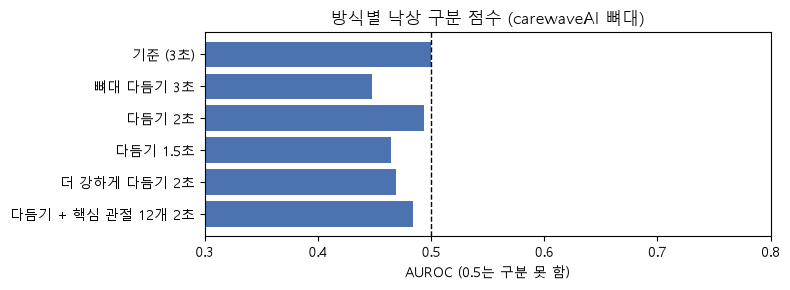

In [30]:
r = pd.read_csv("outputs/pose_variants/results.csv")
r["설명"] = r.variant.map({"base_3s": "기준 (3초)", "ema03_3s": "뼈대 다듬기 3초", "ema03_2s": "다듬기 2초", "ema03_1.5s": "다듬기 1.5초",
                          "ema015_2s": "더 강하게 다듬기 2초", "ema03_core12_2s": "다듬기 + 핵심 관절 12개 2초"})
display(r[["설명", "classifier", "AUROC", "AUPRC", "chance_AUPRC"]].rename(columns={"classifier": "분류기", "chance_AUPRC": "찍기 수준 AUPRC"}).round(3))
gb = r[r.classifier == "GBM"]
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(gb["설명"][::-1], gb.AUROC[::-1], color="#4c72b0")
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set_xlim(0.3, 0.8)
ax.set_xlabel("AUROC (0.5는 구분 못 함)")
ax.set_title("방식별 낙상 구분 점수 (carewaveAI 뼈대)")
plt.tight_layout()
plt.show()

**해석:**
- **표·그림의 뜻:** 방식별 낙상 구분 점수입니다. AUROC는 0.5가 동전 던지기, 1.0이 완벽입니다. AUPRC는 오른쪽 열의 "찍기 수준"보다 얼마나 높은지를 봅니다.
- **좋은 값:** AUROC 0.9 이상, AUPRC는 찍기 수준의 몇 배 이상입니다.
- **지금:** 모든 방식이 AUROC 0.43 ~ 0.50으로 동전 던지기 수준입니다. 가장 높은 AUPRC 0.064(1.5초 창)도 찍기 수준 0.043과 차이가 작아 의미를 두기 어렵습니다.
- **결론:** 뼈대를 다듬거나 창을 줄이거나 관절 수를 줄여도 나아지지 않았습니다. 입력 뼈대 자체에 낙상 신호가 부족하다는 뜻입니다.

그 밖에 시도한 것도 결과는 같았습니다.

| 시도 | AUROC |
|---|---|
| 낙상 뒤 누운 구간을 "낙상 아님"으로 넣는 라벨 수정 | 0.49 |
| 1차 모델이 뼈대를 만들기 직전의 내부 값 128개 사용 | 0.49 |
| 각 녹화의 최근 30초 평소 값으로 나눈 상대 특징 | 0.57 |
| 1차 모델을 더 오래 다시 학습 (뼈대 오차 0.137에서 0.115로 개선) | 0.50 (교차검증), 0.77 (18개 세션) |

## 6. 결론과 다음 단계

### 목표 대비 판정

| 목표 | 결과 | 근거 |
|---|---|---|
| 1차 예측 좌표만으로 Pose 파이프라인 만들기 | 달성 | 2~4절 |
| 학습에 쓴 영상으로 점수가 부풀려지지 않게 평가하기 | 달성 | 3절(다시 학습), TEST 1번 |
| 낙상 사건 90% 이상 알림, 시간당 오탐 1건 미만 | 부분 달성 (정답 뼈대만 알림 비율 충족, 오탐은 모두 미달) | 5.8 |
| 팀의 1차 뼈대로 낙상 구분하기 | 약함 (AUROC 약 0.77, 95% 범위 0.57 ~ 0.97로 넓음) | 5.1 |
| 융합했을 때 CSI 단독보다 좋아지는가 | 아직 확인 안 함 | Pose 단독만 다뤘음 |

### 결론
Pose 모델은 뼈대가 정확하면 낙상을 거의 완벽하게 구분합니다. 그러나 팀의 1차 뼈대는 낙상 움직임을 충분히 담지 못해서 성능이 낮습니다. 성능은 Pose 모델보다 **입력 뼈대의 품질**이 좌우합니다.

### 한계
- 사람이 3명(sujin, yena, hoyeon)뿐이고 낙상 사건이 약 100개라서, 새로운 사람이나 방에서의 성능은 확인하지 못했습니다.
- 검증과 TEST의 낙상이 적어서 점수가 반복마다 크게 흔들립니다.
- 시간당 오탐은 서 있는 시간이 짧아 값이 불안정합니다.
- carewaveTest는 팀의 1차 모델이 아니라 비교용입니다. carewaveAI 뼈대와의 차이는 세션 18개로는 확정할 수 없습니다(5.1의 범위가 겹침).
- carewaveTest 뼈대가 더 잘 구분하는 것처럼 보이는 이유는 확인하지 못했습니다. 그 모델은 학습할 때 낙상 녹화에 가중치를 3배 주고, 뼈 길이와 시간 흐름이 부드럽게 나오게 하는 손실을 추가했고, 입력 창이 1초입니다.

### 다음 단계
1. 융합 담당자와 함께 Pose를 CSI 모델에 붙여서 CSI 단독보다 좋아지는지 확인하기. 뼈대를 못 믿을 때는 품질 게이트로 Pose 영향을 줄이기.
2. 1차 모델을 낙상 구간에 더 신경 쓰도록 학습하면 Pose 성능이 오를 가능성이 있음(1차 모델 담당자와 논의).
3. 알림 판단 방식(연속 확인 조건, 기준값)을 다듬어서 오탐 줄이기. 정답 뼈대에서도 시간당 오탐이 5~12건이라 목표(1건 미만)에는 못 미칩니다.